# Multitemporal assessment of vegetation cover loss in agricultural frontier areas of Galapagos using synthetic aperture radar (Sentinel-1)

##                          Lander Lliguicota & Marck Chiza

# Problem stament

The Galápagos Islands represent one of the most ecologically sensitive and biodiverse archipelagos on the planet, yet they face mounting anthropogenic pressure driven by population growth and agricultural expansion in human-inhabited zones. While most remote sensing studies of the Galápagos have focused on Santa Cruz Island, this project deliberately targets Isla Isabela — the largest and most volcanically active island in the archipelago — where deforestation dynamics near the southern settlement of Puerto Villamil remain critically understudied. \\

Isabela's southern zone sits at the intersection of active human settlement and extraordinarily fragile endemic ecosystems. The areas surrounding Sierra Negra, Cerro Azul, and Volcán Alcedo host unique vegetation communities that are increasingly threatened by agricultural frontier expansion, invasive species encroachment, and informal land-use change radiating outward from Puerto Villamil. Despite this urgency, the island's persistent cloud cover and logistical remoteness make conventional optical satellite monitoring unreliable and infrequent.\\

This project leverages Sentinel-1 Synthetic Aperture Radar (SAR) imagery to overcome these limitations, analyzing temporal backscatter changes across four strategically selected bounding boxes on Isla Isabela:

# Dataset 


Sentinel-1 is an Earth observation dataset obtained by synthetic aperture radar (SAR) satellites of the Copernicus Programme. It provides images of the Earth's surface independent of sunlight and weather conditions, enabling the monitoring of phenomena such as flooding, land-use change, sea ice, and ground deformation.
| Zone | BBox | Rationale |
|---|---|---|
| Sierra Negra Sur | [-91.05, -0.90, -90.95, -0.80] | Agricultural slopes near volcanic activity |
| Villamil Expansión | [-91.00, -0.95, -90.90, -0.85] | Direct periurban pressure from Puerto Villamil |
| Cerro Azul Este | [-91.30, -0.95, -91.20, -0.85] | Isolated eastern flank, secondary expansion risk |
| Volcán Alcedo Sur | [-91.15, -0.50, -91.05, -0.40] | Northernmost buffer zone, baseline reference |


## Sentinel-1 SAR — Key Parameters

| Parameter | Value |
|---|---|
| Sensor | Sentinel-1 IW (Interferometric Wide Swath) |
| Polarization | VV + VH (dual-pol) |
| Product type | GRD (Ground Range Detected) |
| Spatial resolution | ~10 m (resampled to 512×512 px per BBox) |
| Temporal coverage | 2017 – 2026 (Q1 mosaic per year) |
| Time interval per scene | Jan 1 – Mar 31 of each year |
| Acquisition | SentinelHub API via evalscript |
| Output format | GeoTIFF (FLOAT32, linear power) |

### Polarization Channels

**VV (Vertical-Vertical):**  
Sensitive to surface roughness and soil moisture. 
Used to create the land/sea mask (water = low VV, land = high VV).

**VH (Vertical-Horizontal):**  
Cross-polarization sensitive to vegetation volume and canopy structure.  
Used for change detection — forest loss causes a measurable VH backscatter drop.


# Pipeline
## Core Processing Pipeline

1. **SAR Backscatter Conversion**

Sentinel-1 provides radar backscatter intensity values. These values are converted to the **decibel scale (dB)** using a logarithmic transformation:

\[
dB = 10 \log_{10}(x)
\]

This transformation compresses the dynamic range and makes structural differences in the surface easier to detect.

---

2. **Normalization**

The backscatter values are normalized to the **0–255 range**. This allows the SAR data to be processed using standard computer vision techniques such as thresholding and morphological filtering.

---

3. **Gaussian Blur (Speckle Reduction)**

SAR images contain **speckle noise**, caused by coherent radar interference.  
A **Gaussian blur filter** smooths local pixel variations by averaging neighboring pixels, reducing high-frequency noise while preserving large structures.

---

4. **Land Mask via Thresholding**

Water surfaces produce **very low radar backscatter**, while land surfaces produce higher values.  
A **binary threshold** separates land from ocean, generating a **land mask** to exclude ocean pixels from further analysis.

---

5. **Morphological Filtering**

Morphological operations clean the binary mask:

- **Opening (erosion → dilation):** removes small noisy regions.
- **Closing (dilation → erosion):** fills small gaps and smooths boundaries.

This produces a stable segmentation of land areas.

---

6. **Temporal Change Detection**

A **baseline year (2017)** is used as reference.  
For each later year, the **absolute difference** between VH polarization images is computed:

\[
\Delta = |VH_{t} - VH_{baseline}|
\]

This highlights locations where radar backscatter has significantly changed over time.

---

7. **Change Thresholding**

A second threshold isolates **strong backscatter variations**, filtering out minor fluctuations caused by noise or seasonal effects.

---

8. **Morphological Noise Removal**

A small morphological opening removes isolated pixels and retains only spatially coherent change regions.

---

9. **Contour Detection and Area Filtering**

Connected regions of change are detected using **contours**.  
Very small regions are removed using a **minimum area threshold**, reducing false positives.

---

10. **Result**

The final regions represent **significant structural surface changes**, which may correspond to **deforestation, agricultural expansion, or land-use change** near populated areas in the Galápagos Islands.



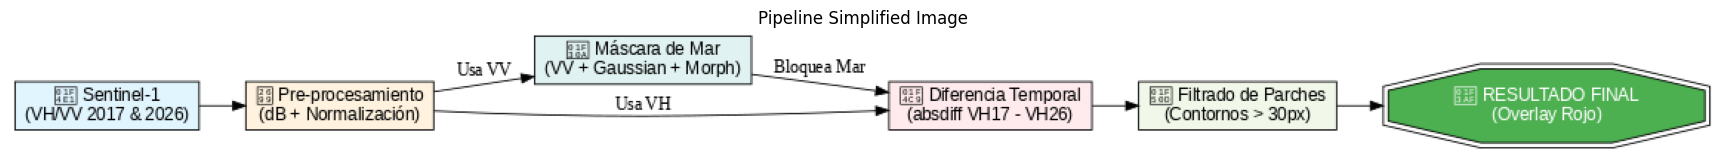

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

image_path = './Pipeline_Simplificado.png'
img = mpimg.imread(image_path)

plt.figure(figsize=(22, 10))
plt.imshow(img)
plt.axis('off') # Hide axes ticks and labels
plt.title('Pipeline Simplified Image')
plt.show()

# Pipeline Justification (Unsupervised Approach)
* **dB Conversion & Normalization:** Transforms SAR dynamic range into 8-bit (0-255) to leverage optimized OpenCV functions.
* **Land/Sea Mask (VV):** Water acts as a specular reflector (low VV). Gaussian blur + threshold (45) + morphology effectively isolates land and removes wave noise.
* **Deforestation Detection (VH):** VH backscatter is highly sensitive to canopy volume. `cv2.absdiff` combined with a strict threshold (45) and area filtering (>30px) isolates severe biomass loss while ignoring SAR speckle.

### Future Work: Supervised Learning (Random Forest)
To upgrade from empirical thresholds to a predictive model:
* **Features ($X$):** The model must train on raw physical backscatter (dB), not the normalized 8-bit arrays, which lose absolute physical meaning.
* **Labels ($y$):** Requires external Ground Truth polygons. Training on the current binary masks would merely teach the model to replicate the `absdiff > 45` mathematical rule.

In [2]:
# ==============================================================================
# 1. IMPORTS Y CONFIGURACIÓN SEGURA DE CREDENCIALES

# ==============================================================================
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sentinelhub import BBox, CRS, MimeType, SentinelHubRequest, DataCollection, SHConfig

# Buscar y cargar las variables ocultas del archivo .env
load_dotenv()

# Inicializar la configuración de Sentinel Hub
config = SHConfig()

# Asignar las credenciales jalándolas del entorno de tu compu
config.instance_id = os.getenv('SH_INSTANCE_ID')
config.sh_client_id = os.getenv('SH_CLIENT_ID')
config.sh_client_secret = os.getenv('SH_CLIENT_SECRET')



Running Sentinel-1 change detection...

Processing area: Sierra Negra Sur
2018: 0 detected patches
2020: 16 detected patches
2022: 0 detected patches
2026: 2 detected patches


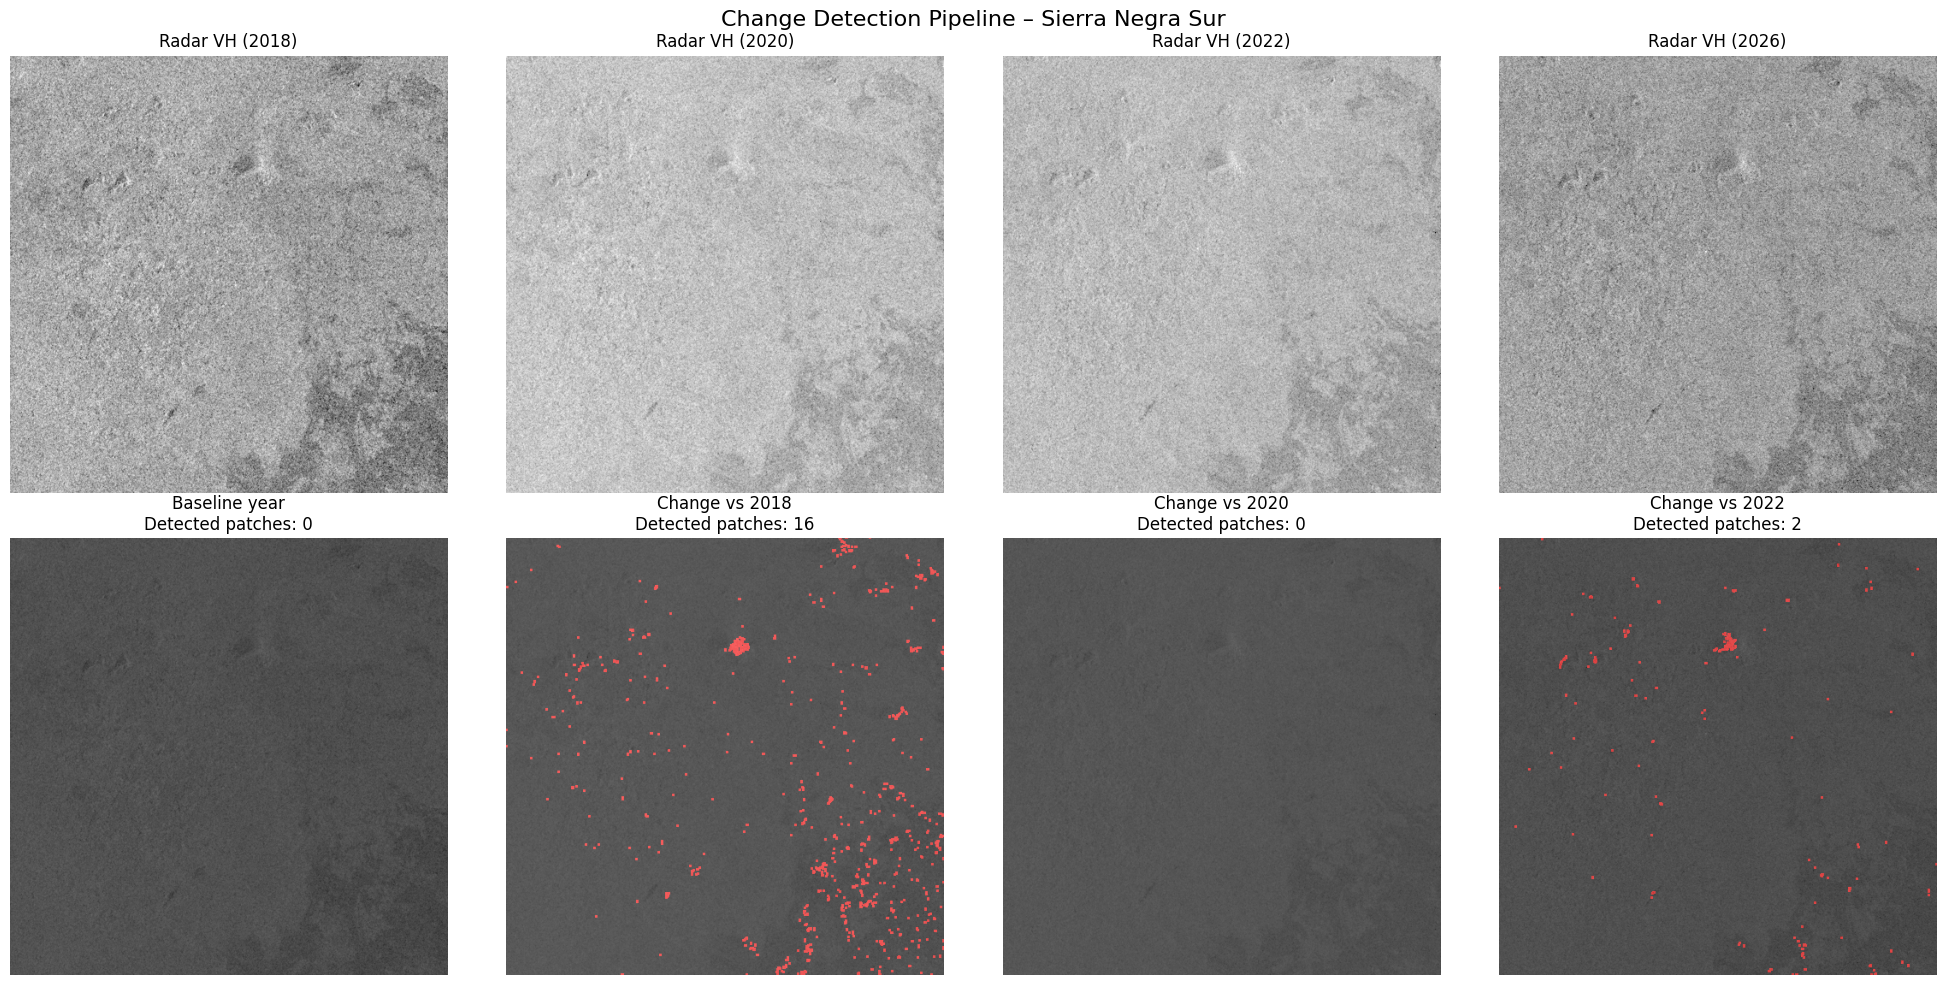


Processing area: Villamil Expansion
2018: 0 detected patches
2020: 1 detected patches
2022: 0 detected patches
2026: 2 detected patches

Processing area: Cerro Azul Este
2018: 0 detected patches
2020: 1 detected patches
2022: 1 detected patches
2026: 9 detected patches

Processing area: Volcan Alcedo Sur
2018: 0 detected patches
2020: 3 detected patches
2022: 0 detected patches
2026: 1 detected patches


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sentinelhub import BBox, CRS, MimeType, SentinelHubRequest, DataCollection

# ----------------------------------
# Areas of Interest
# ----------------------------------
areas = {
    "Sierra Negra Sur": BBox(bbox=[-91.05, -0.90, -90.95, -0.80], crs=CRS.WGS84),
    "Villamil Expansion": BBox(bbox=[-91.00, -0.95, -90.90, -0.85], crs=CRS.WGS84),
    "Cerro Azul Este": BBox(bbox=[-91.30, -0.95, -91.20, -0.85], crs=CRS.WGS84),
    "Volcan Alcedo Sur": BBox(bbox=[-91.15, -0.50, -91.05, -0.40], crs=CRS.WGS84)
}

# Demo area for visualization
demo_area = "Sierra Negra Sur"

# ----------------------------------
# Sentinel-1 evalscript
# ----------------------------------
evalscript_s1 = """
//VERSION=3
function setup() {
    return {
        input: ["VV", "VH"],
        output: [
            { id: "vv", bands: 1, sampleType: "FLOAT32" },
            { id: "vh", bands: 1, sampleType: "FLOAT32" }
        ]
    };
}

function evaluatePixel(sample) {
    return {
        vv: [sample.VV],
        vh: [sample.VH]
    };
}
"""

# ----------------------------------
# Download Sentinel-1
# ----------------------------------
def download_sentinel1(year, bbox, config, area_name):

    folder = f"sentinel1_evolution/{area_name}/{year}"
    os.makedirs(folder, exist_ok=True)

    request = SentinelHubRequest(
        data_folder=folder,
        evalscript=evalscript_s1,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW,
                time_interval=(f"{year}-01-01", f"{year}-03-31")
            )
        ],
        responses=[
            SentinelHubRequest.output_response("vv", MimeType.TIFF),
            SentinelHubRequest.output_response("vh", MimeType.TIFF)
        ],
        bbox=bbox,
        size=(512, 512),
        config=config,
    )

    return request.get_data(save_data=True)[0]


# ----------------------------------
# Backscatter processing
# ----------------------------------
def process_backscatter(data, band):

    arr = data[f"{band}.tif"].squeeze()

    arr_db = 10 * np.log10(arr + 1e-4)

    arr_norm = cv2.normalize(
        arr_db,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return np.uint8(arr_norm)


# ----------------------------------
# Analysis years
# ----------------------------------
years = ["2018", "2020", "2022", "2026"]

print("Running Sentinel-1 change detection...")

for area_name, bbox in areas.items():

    print(f"\nProcessing area: {area_name}")

    yearly_data = [
        download_sentinel1(y, bbox, config, area_name)
        for y in years
    ]

    vv_base = process_backscatter(yearly_data[0], "vv")
    vh_base = process_backscatter(yearly_data[0], "vh")

    # ----------------------------------
    # Land mask from VV
    # ----------------------------------

    vv_blur = cv2.GaussianBlur(vv_base, (5,5), 0)

    _, land_mask = cv2.threshold(
        vv_blur,
        45,
        255,
        cv2.THRESH_BINARY
    )

    kernel = np.ones((7,7), np.uint8)

    land_mask = cv2.morphologyEx(
        land_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    land_mask = cv2.morphologyEx(
        land_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    detected_patches = []

    # ----------------------------------
    # Visualization (only demo area)
    # ----------------------------------

    if area_name == demo_area:

        fig, axes = plt.subplots(2,4, figsize=(20,10))
        axes = axes.flatten()

    prev_vh_land = None

    for i, (data_year, year) in enumerate(zip(yearly_data, years)):

        vh_current = process_backscatter(data_year, "vh")

        vh_land = cv2.bitwise_and(
            vh_current,
            vh_current,
            mask=land_mask
        )

        if i == 0:

            diff = np.zeros_like(vh_land)
            prev_vh_land = vh_land.copy()

            label = "Baseline year"

        else:

            diff = cv2.absdiff(prev_vh_land, vh_land)
            prev_vh_land = vh_land.copy()

            label = f"Change vs {years[i-1]}"

        _, change_mask = cv2.threshold(
            diff,
            45,
            255,
            cv2.THRESH_BINARY
        )

        change_mask = cv2.morphologyEx(
            change_mask,
            cv2.MORPH_OPEN,
            np.ones((3,3), np.uint8)
        )

        contours, _ = cv2.findContours(
            change_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        valid = [
            c for c in contours
            if cv2.contourArea(c) > 30
        ]

        detected_patches.append(len(valid))

        if area_name == demo_area:

            overlay = np.zeros((512,512,3), dtype=np.uint8)
            overlay[:,:,0] = change_mask

            axes[i].imshow(vh_land, cmap="gray")
            axes[i].set_title(f"Radar VH ({year})")
            axes[i].axis("off")

            axes[i+4].imshow(vh_land, cmap="gray", alpha=0.6)
            axes[i+4].imshow(overlay, alpha=0.6)

            axes[i+4].set_title(
                f"{label}\nDetected patches: {len(valid)}"
            )

            axes[i+4].axis("off")

    for y, p in zip(years, detected_patches):

        print(f"{y}: {p} detected patches")

    if area_name == demo_area:

        plt.suptitle(
            f"Change Detection Pipeline – {area_name}",
            fontsize=16
        )

        plt.tight_layout()

        os.makedirs("results", exist_ok=True)

        plt.savefig(
            "results/complete.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

## Limitations and Failures

Several limitations affect the reliability of this preliminary approach.

- **Empirical thresholds:** The selected thresholds are heuristic and not statistically optimized.
- **Non-specific change detection:** The method detects any strong radar backscatter change, which may also include flooding, volcanic ash, or seasonal vegetation variation.
- **SAR noise and terrain effects:** Speckle noise and slope orientation relative to the radar sensor may generate false positives.
- **Limited temporal sampling:** Using only a few reference years may miss gradual land-use changes.

Because of these factors, the detected patches should be interpreted as **potential change indicators rather than confirmed deforestation events**.


---

## Conclusions

This preliminary study demonstrates that **Sentinel-1 SAR imagery can be used to identify structural land surface changes in the Galápagos Islands without labeled data**.

The unsupervised threshold-based pipeline allows rapid detection of candidate deforestation areas near human settlements using only radar backscatter differences.

While the method is simple and scalable, its results should be considered **exploratory**. Future work should incorporate **multi-temporal datasets, additional environmental features, and supervised or spatio-temporal machine learning models** to improve prediction accuracy and reduce false detections.